### For Presentation - 

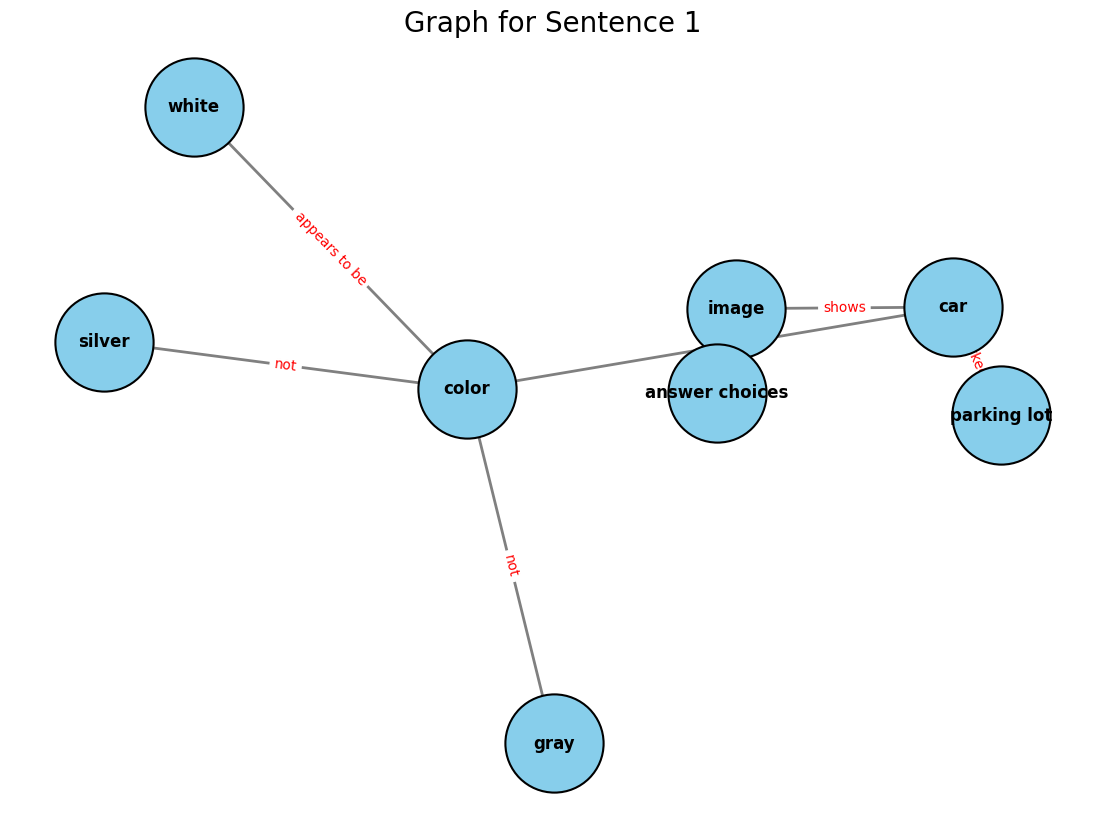

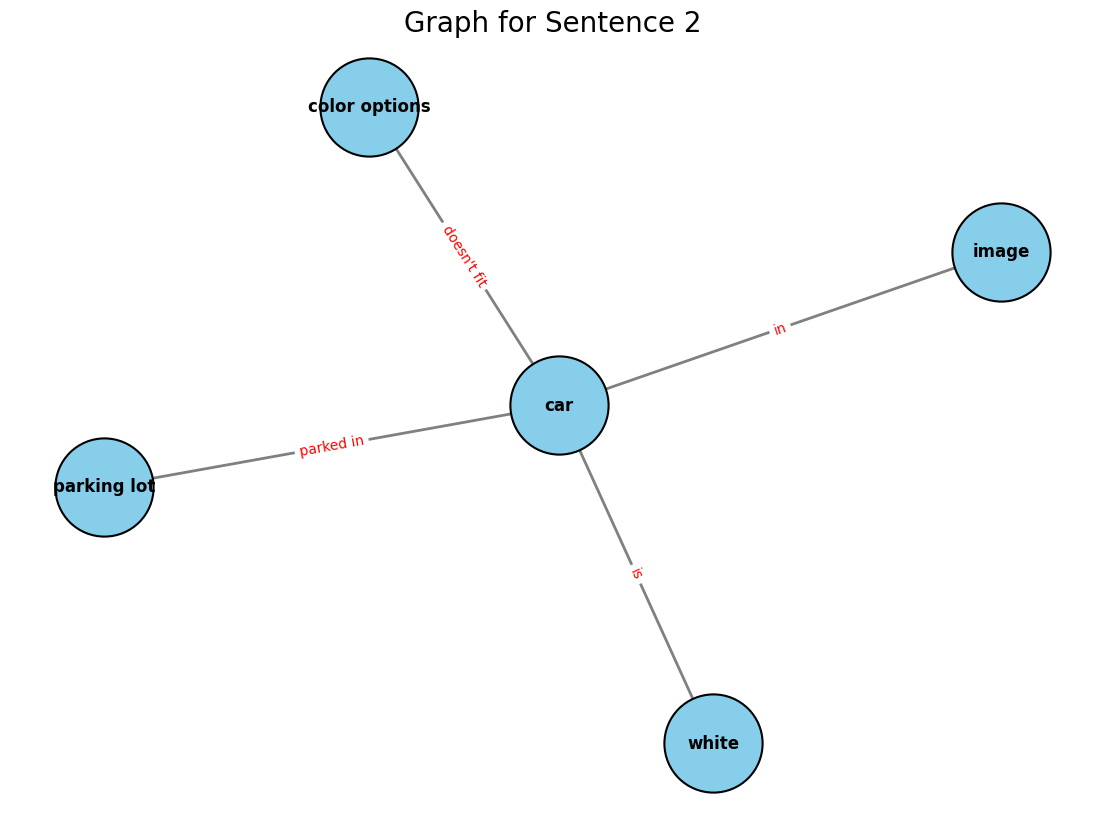

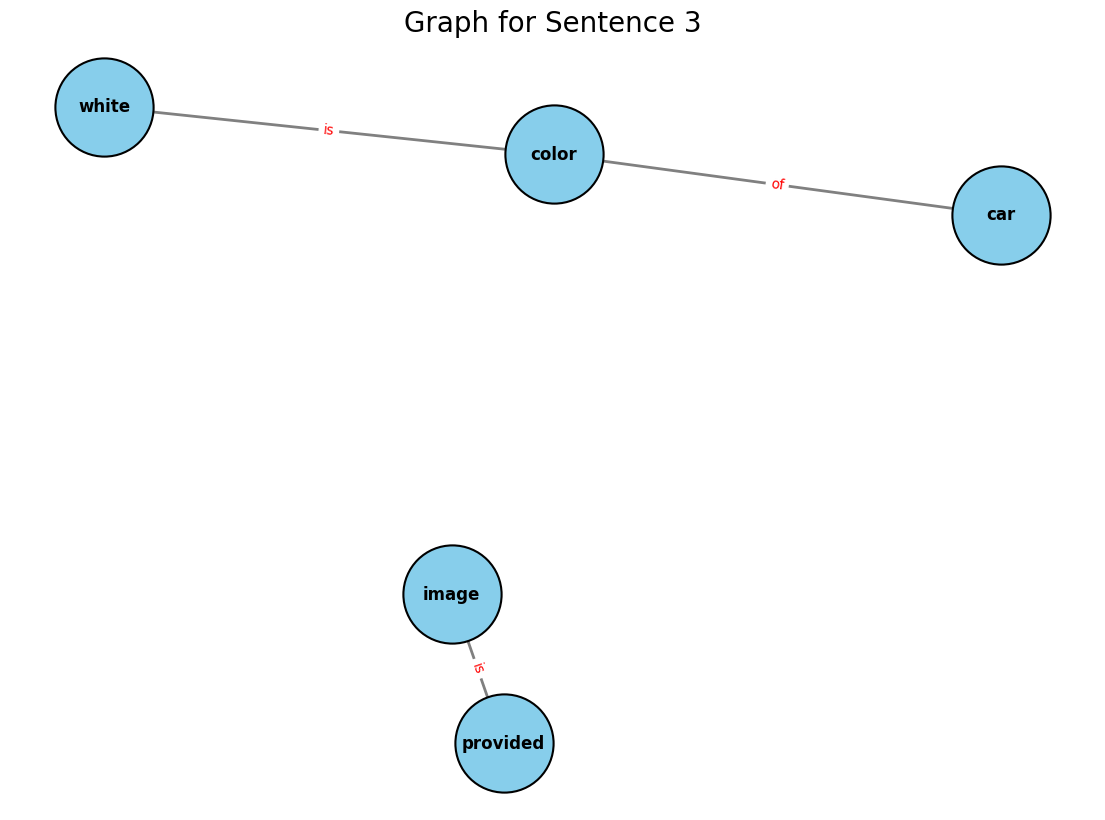

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

def create_graph(entities, relationships):
    G = nx.DiGraph()

    for entity in entities:
        G.add_node(entity)

    for rel in relationships:
        G.add_edge(rel[0], rel[1], label=rel[2])

    return G

def draw_graph(G, title):
    pos = nx.spring_layout(G, k=0.5)
    labels = nx.get_edge_attributes(G, 'label')
    node_labels = {node: node for node in G.nodes()}

    plt.figure(figsize=(14, 10))

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=5000, node_color="skyblue", edgecolors='black', linewidths=1.5)

    # Draw edges
    nx.draw_networkx_edges(G, pos, width=2, arrowstyle='->', arrowsize=20, edge_color="gray")

    # Draw node labels
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=12, font_weight="bold", verticalalignment='center', horizontalalignment='center')

    # Draw edge labels
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_color="red", font_size=10, verticalalignment='center', horizontalalignment='center')

    plt.title(title, size=20)
    plt.axis('off')
    plt.show()

# Sentence 1
entities1 = ["image", "car", "parking lot", "color", "answer choices"]
relationships1 = [("image", "car", "shows"),
                  ("car", "parking lot", "parked in"),
                  ("color", "car", "of"),
                  ("color", "white", "appears to be"),
                  ("color", "silver", "not"),
                  ("color", "gray", "not"),
                  ("answer choices", "image", "suggest")]

G1 = create_graph(entities1, relationships1)
draw_graph(G1, "Graph for Sentence 1")

# Sentence 2
entities2 = ["image", "car", "parking lot", "color options"]
relationships2 = [("car", "image", "in"),
                  ("car", "white", "is"),
                  ("car", "parking lot", "parked in"),
                  ("car", "color options", "doesn't fit")]

G2 = create_graph(entities2, relationships2)
draw_graph(G2, "Graph for Sentence 2")

# Sentence 3
entities3 = ["image", "car", "color"]
relationships3 = [("image", "provided", "is"),
                  ("color", "car", "of"),
                  ("color", "white", "is")]

G3 = create_graph(entities3, relationships3)
draw_graph(G3, "Graph for Sentence 3")

In [3]:
# !pip install sng-parser
!pip install SceneGraphParser


In [4]:

# # Visualize the graphs
# def visualize_graphs(graphs, titles):
#     plt.figure(figsize=(15, 10))
#     for i, G in enumerate(graphs):
#         plt.subplot(3, 3, i + 1)
#         pos = nx.spring_layout(G)
#         labels = nx.get_node_attributes(G, 'label')
#         nx.draw(G, pos, labels=labels, with_labels=True, node_color='skyblue', edge_color='gray', node_size=3000, font_size=10)
#         plt.title(titles[i])
#     plt.tight_layout()
#     plt.show()

# # Titles for the graphs
# titles = [f"Graph {i + 1}" for i in range(len(graphs))]

# # Visualize the graphs
# visualize_graphs(graphs, titles)

In [5]:
# !pip install grakel
# !pip install networkx
# !pip install spacy
# !python -m spacy download en_core_web_sm


## Constructs a kernel matrix using the Weisfeiler-Lehman kernel provided by GraKeL, which compares graph structures more robustly.

In [ ]:
import spacy
from grakel import GraphKernel, Graph
import networkx as nx
import numpy as np

nlp = spacy.load("en_core_web_sm")

sentences = {
    "S2": {
        "ground_truth": "The dog barked loudly at the stranger.",
        "variations": [
            "A girl is dancing in the stadium.",
            "A girl is dancing in the stadium.",
            "A girl is dancing in the stadium.",
        ]
    }
}

def extract_entities_and_relationships(sentence):
    doc = nlp(sentence)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    relationships = []
    for token in doc:
        if token.dep_ in ["ROOT", "VERB"]:
            for child in token.children:
                if child.dep_ in ["nsubj", "dobj", "pobj", "prep", "advmod"]:
                    relationships.append((token.lemma_, child.text, child.dep_))
        elif token.pos_ == "ADP":  # for prepositions
            for child in token.children:
                if child.dep_ == "pobj":
                    relationships.append((token.text, child.text, "prep_obj"))
    if not entities:
        for chunk in doc.noun_chunks:
            entities.append((chunk.text, 'NOUN_CHUNK'))
    return entities, relationships

def construct_graph(entities, relationships):
    G = nx.DiGraph()
    for entity, label in entities:
        G.add_node(entity, label=label)
    for subj, obj, dep in relationships:
        if not G.has_node(subj):
            G.add_node(subj, label="VERB")
        if not G.has_node(obj):
            G.add_node(obj, label="NOUN")
        G.add_edge(subj, obj, label=dep)
    return G

# Extract entities and relationships, then construct graphs
graphs = []
ground_truth_indices = {}
index = 0

all_sentences = []
for key, data in sentences.items():
    ground_truth = data["ground_truth"]
    all_sentences.append(ground_truth)
    ground_truth_indices[key] = index
    index += 1
    for sentence in data["variations"]:
        all_sentences.append(sentence)
        index += 1

for sentence in all_sentences:
    entities, relationships = extract_entities_and_relationships(sentence)
    print(f"Sentence: {sentence}")
    print(f"Entities: {entities}")
    print(f"Relationships: {relationships}")
    G = construct_graph(entities, relationships)
    graphs.append(G)

for G in graphs:
    for node in G.nodes:
        if 'label' not in G.nodes[node]:
            G.nodes[node]['label'] = 'unknown'
        G.nodes[node]['label'] = str(G.nodes[node]['label'])
    print(f"Graph Nodes: {G.nodes(data=True)}")
    print(f"Graph Edges: {G.edges(data=True)}")

grakel_graphs = []
for G in graphs:
    if len(G.nodes) > 0:
        # Create an adjacency matrix
        adj_matrix = nx.adjacency_matrix(G).todense()
        # Create node labels dictionary
        node_labels = {i: G.nodes[node]['label'] for i, node in enumerate(G.nodes)}
        # Create edge labels dictionary
        edge_labels = {(i, j): G.edges[u, v]['label']
                       for i, u in enumerate(G.nodes)
                       for j, v in enumerate(G.nodes)
                       if G.has_edge(u, v)}
        grakel_graphs.append(Graph(adj_matrix, node_labels=node_labels, edge_labels=edge_labels))

# Check if we have any valid graphs
if not grakel_graphs:
    print("No valid graphs were created. Check your sentence parsing and graph construction.")
else:
    gk = GraphKernel(kernel={"name": "weisfeiler_lehman", "n_iter": 3}, normalize=True)
    K = gk.fit_transform(grakel_graphs)

    print("Kernel matrix:\n", K)

    alpha = 0.5
    beta = 0.5

    uncertainty = {}
    for key, data in sentences.items():
        ground_truth_index = ground_truth_indices[key]
        print(f"Using ground truth sentence for {key}: '{all_sentences[ground_truth_index]}'")
        similarities_within_group = []
        similarities_with_ground_truth = []

        for i in range(1, len(data["variations"]) + 1):
            for j in range(i + 1, len(data["variations"]) + 1):
                index_i = ground_truth_index + i
                index_j = ground_truth_index + j
                if index_i < len(K) and index_j < len(K):
                    similarity = K[index_i, index_j]
                    similarities_within_group.append(similarity)

        for i in range(1, len(data["variations"]) + 1):
            index_i = ground_truth_index + i
            if index_i < len(K):
                similarity = K[ground_truth_index, index_i]
                similarities_with_ground_truth.append(similarity)

        avg_similarity_within_group = np.mean(similarities_within_group) if similarities_within_group else 0
        avg_similarity_with_ground_truth = np.mean(similarities_with_ground_truth) if similarities_with_ground_truth else 0

        uncertainty[key] = alpha * (1 - avg_similarity_within_group) + beta * (1 - avg_similarity_with_ground_truth)

        print(f"Average similarity within group for {key}: {avg_similarity_within_group:.4f}")
        print(f"Average similarity with ground truth for {key}: {avg_similarity_with_ground_truth:.4f}")
        print(f"Uncertainty for {key}: {uncertainty[key]:.4f}")

        print(f"Similarities within group for {key}: {similarities_within_group}")
        print(f"Similarities with ground truth for {key}: {similarities_with_ground_truth}")

Sentence: The dog barked loudly at the stranger.
Entities: [('The dog', 'NOUN_CHUNK'), ('the stranger', 'NOUN_CHUNK')]
Relationships: [('at', 'stranger', 'prep_obj')]
Sentence: A girl is dancing in the stadium.
Entities: [('A girl', 'NOUN_CHUNK'), ('the stadium', 'NOUN_CHUNK')]
Relationships: [('dance', 'girl', 'nsubj'), ('dance', 'in', 'prep'), ('in', 'stadium', 'prep_obj')]
Sentence: A girl is dancing in the stadium.
Entities: [('A girl', 'NOUN_CHUNK'), ('the stadium', 'NOUN_CHUNK')]
Relationships: [('dance', 'girl', 'nsubj'), ('dance', 'in', 'prep'), ('in', 'stadium', 'prep_obj')]
Sentence: A girl is dancing in the stadium.
Entities: [('A girl', 'NOUN_CHUNK'), ('the stadium', 'NOUN_CHUNK')]
Relationships: [('dance', 'girl', 'nsubj'), ('dance', 'in', 'prep'), ('in', 'stadium', 'prep_obj')]
Graph Nodes: [('The dog', {'label': 'NOUN_CHUNK'}), ('the stranger', {'label': 'NOUN_CHUNK'}), ('at', {'label': 'VERB'}), ('stranger', {'label': 'NOUN'})]
Graph Edges: [('at', 'stranger', {'label':

## Constructs a kernel matrix using a custom kernel function that combines node and structure similarities.

In [ ]:
import spacy
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from grakel import Graph, GraphKernel

nlp = spacy.load("en_core_web_sm")

def extract_entities_and_relationships(sentence):
    doc = nlp(sentence)
    entities = [(ent.text, ent.vector) for ent in doc.ents]
    relationships = []
    for token in doc:
        if token.dep_ in ["ROOT", "VERB"]:
            for child in token.children:
                if child.dep_ in ["nsubj", "dobj", "pobj", "prep", "advmod"]:
                    relationships.append((token.lemma_, child.text, child.dep_, token.vector, child.vector))
    if not entities:
        for chunk in doc.noun_chunks:
            entities.append((chunk.text, chunk.vector))
    return entities, relationships

def construct_graph(entities, relationships):
    nodes = {}
    edges = []
    for i, (text, vector) in enumerate(entities):
        nodes[i] = {'label': text, 'vector': vector}

    for i, (subj, obj, dep, subj_vec, obj_vec) in enumerate(relationships, start=len(entities)):
        if subj not in nodes:
            nodes[i] = {'label': subj, 'vector': subj_vec}
        if obj not in nodes:
            nodes[i+1] = {'label': obj, 'vector': obj_vec}
        edges.append((i, i+1))

    return nodes, edges

def custom_kernel(graph1, graph2):
    # Compare node vectors
    vectors1 = np.array([node['vector'] for node in graph1[0].values()])
    vectors2 = np.array([node['vector'] for node in graph2[0].values()])

    # Compute cosine similarity between all pairs of vectors
    similarity_matrix = cosine_similarity(vectors1, vectors2)

    # Take the average similarity
    node_similarity = np.mean(similarity_matrix)

    # Compare graph structures (you can adjust this part)
    structure_similarity = 1 if len(graph1[1]) == len(graph2[1]) else 0

    # Combine node and structure similarity (you can adjust the weights)
    return 0.5 * node_similarity + 0.5 * structure_similarity

# sentences = {
#     "S1": {
#         "ground_truth": "The dog barked loudly at the stranger.",
#         "variations": [
#             "A girl is dancing in the stadium.",
#             "The cat meowed softly on the windowsill.",
#             "The dog growled at the intruder.",
#         ]
#     },
#     "S2": {
#         "ground_truth": "The scientist conducted an experiment in the laboratory.",
#         "variations": [
#             "A researcher performed a test in the lab.",
#             "The chemist mixed chemicals in the laboratory.",
#             "An experiment was carried out by the scientist.",
#         ]
#     },
#     "S3": {
#         "ground_truth": "The chef prepared a delicious meal for the guests.",
#         "variations": [
#             "The cook made a tasty dinner for the visitors.",
#             "A gourmet dish was created by the chef.",
#             "The baker baked a cake for the party.",
#         ]
#     }
# }

sentences = {
    "S2": {
        "ground_truth": "The dog barked loudly at the stranger.",
        "variations": [
            "A girl is dancing in the stadium.",
            "A girl is dancing in the stadium.",
            "A girl is dancing in the stadium.",
        ]
    }
}

graphs = []
for key, data in sentences.items():
    all_sentences = [data["ground_truth"]] + data["variations"]
    for sentence in all_sentences:
        entities, relationships = extract_entities_and_relationships(sentence)
        graph = construct_graph(entities, relationships)
        graphs.append(graph)

# Compute custom kernel matrix
n = len(graphs)
K = np.zeros((n, n))
for i in range(n):
    for j in range(i, n):
        K[i, j] = custom_kernel(graphs[i], graphs[j])
        K[j, i] = K[i, j]  # Kernel matrix is symmetric

print("Kernel matrix:\n", K)

# Compute uncertainty (similar to before)
alpha = 0.5
beta = 0.5

uncertainty = {}
for key, data in sentences.items():
    ground_truth_index = 0
    similarities_within_group = K[1:, 1:][np.triu_indices(len(data["variations"]), k=1)]
    similarities_with_ground_truth = K[0, 1:]

    avg_similarity_within_group = np.mean(similarities_within_group)
    avg_similarity_with_ground_truth = np.mean(similarities_with_ground_truth)

    uncertainty[key] = alpha * (1 - avg_similarity_within_group) + beta * (1 - avg_similarity_with_ground_truth)

    print(f"Average similarity within group for {key}: {avg_similarity_within_group:.4f}")
    print(f"Average similarity with ground truth for {key}: {avg_similarity_with_ground_truth:.4f}")
    print(f"Uncertainty for {key}: {uncertainty[key]:.4f}")

Kernel matrix:
 [[0.77562672 0.11289974 0.11289974 0.11289974]
 [0.11289974 0.66853662 0.66853662 0.66853662]
 [0.11289974 0.66853662 0.66853662 0.66853662]
 [0.11289974 0.66853662 0.66853662 0.66853662]]
Average similarity within group for S2: 0.6685
Average similarity with ground truth for S2: 0.1129
Uncertainty for S2: 0.6093


## Semantic Similarity

In [ ]:
import spacy
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

nlp = spacy.load("en_core_web_sm")

def extract_sentence_features(sentence):
    doc = nlp(sentence)
    return doc.vector

def custom_kernel(feat1, feat2):
    similarity = cosine_similarity(feat1.reshape(1, -1), feat2.reshape(1, -1))[0][0]
    # If sentences are nearly identical (allowing for small floating-point differences)
    if np.allclose(feat1, feat2, atol=1e-6):
        return 1.0
    return similarity

# sentences = {
#     "S1": {
#         "ground_truth": "The dog barked loudly at the stranger.",
#         "variations": [
#             "A girl is dancing in the stadium.",
#             "The cat meowed softly on the windowsill.",
#             "The dog growled at the intruder.",
#         ]
#     },
#     "S2": {
#         "ground_truth": "The scientist conducted an experiment in the laboratory.",
#         "variations": [
#             "A researcher performed a test in the lab.",
#             "The chemist mixed chemicals in the laboratory.",
#             "An experiment was carried out by the scientist.",
#         ]
#     },
#     "S3": {
#         "ground_truth": "The chef prepared a delicious meal for the guests.",
#         "variations": [
#             "The cook made a tasty dinner for the visitors.",
#             "A gourmet dish was created by the chef.",
#             "The baker baked a cake for the party.",
#         ]
#     }
# }
sentences = {
    "S2": {
        "ground_truth": "The dog barked loudly at the stranger.",
        "variations": [
            "A girl is dancing in the stadium.",
            "A girl is dancing in the stadium.",
            "A girl is dancing in the stadium.",
        ]
    }
}

features = []
for key, data in sentences.items():
    all_sentences = [data["ground_truth"]] + data["variations"]
    for sentence in all_sentences:
        features.append(extract_sentence_features(sentence))

# Compute custom kernel matrix
n = len(features)
K = np.zeros((n, n))
for i in range(n):
    for j in range(i, n):
        K[i, j] = custom_kernel(features[i], features[j])
        K[j, i] = K[i, j]  # Kernel matrix is symmetric

print("Kernel matrix:\n", K)

# Compute uncertainty
alpha = 0.5
beta = 0.5

uncertainty = {}
for key, data in sentences.items():
    ground_truth_index = 0
    similarities_within_group = K[1:, 1:][np.triu_indices(len(data["variations"]), k=1)]
    similarities_with_ground_truth = K[0, 1:]

    avg_similarity_within_group = np.mean(similarities_within_group)
    avg_similarity_with_ground_truth = np.mean(similarities_with_ground_truth)

    uncertainty[key] = alpha * (1 - avg_similarity_within_group) + beta * (1 - avg_similarity_with_ground_truth)

    print(f"Average similarity within group for {key}: {avg_similarity_within_group:.4f}")
    print(f"Average similarity with ground truth for {key}: {avg_similarity_with_ground_truth:.4f}")
    print(f"Uncertainty for {key}: {uncertainty[key]:.4f}")

Kernel matrix:
 [[1.         0.61863494 0.61863494 0.61863494]
 [0.61863494 1.         1.         1.        ]
 [0.61863494 1.         1.         1.        ]
 [0.61863494 1.         1.         1.        ]]
Average similarity within group for S2: 1.0000
Average similarity with ground truth for S2: 0.6186
Uncertainty for S2: 0.1907


## Semantic similarity + Word Overlap

In [ ]:
import spacy
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

nlp = spacy.load("en_core_web_sm")

def extract_sentence_features(sentence):
    doc = nlp(sentence)
    # Extract key words (nouns, verbs, adjectives, adverbs)
    key_words = [token.text for token in doc if token.pos_ in ['NOUN', 'VERB', 'ADJ', 'ADV']]
    return doc.vector, key_words

def custom_kernel(feat1, feat2):
    vec1, words1 = feat1
    vec2, words2 = feat2

    # Sentence vector similarity
    vec_similarity = cosine_similarity(vec1.reshape(1, -1), vec2.reshape(1, -1))[0][0]

    # Word overlap similarity
    word_overlap = len(set(words1) & set(words2)) / max(len(set(words1) | set(words2)), 1)

    # If sentences are nearly identical (allowing for small floating-point differences)
    if np.allclose(vec1, vec2, atol=1e-6) and words1 == words2:
        return 1.0

    # Combine vector similarity and word overlap (adjust weights as needed)
    return 0.3 * vec_similarity + 0.7 * word_overlap

# sentences = {
#     # case 1: consistenly wrong
#     "S2": {
#         "ground_truth": "The dog barked loudly at the stranger.",
#         "variations": [
#             "A girl is dancing in the stadium.",
#             "A girl is dancing in the stadium.",
#             "A girl is dancing in the stadium.",
#         ],
#     },
#     # case 2: consistently right
#     "S5": {
#         "ground_truth": "Birds are singing in the morning.",
#         "variations": [
#             "Birds are chirping at dawn.",
#             "In the early morning, birds are singing.",
#             "The morning is filled with birds singing.",
#             "Birdsong fills the air in the morning.",
#             "Morning is when birds sing the loudest."
#         ],
#     }
# }

sentences = {
    "S1": {
        "ground_truth": "The dog barked loudly at the stranger.",
        "variations": [
            "A girl is dancing in the stadium.",
            "The cat meowed softly on the windowsill.",
            "The dog growled at the intruder.",
        ]
    },
    "S2": {
        "ground_truth": "The scientist conducted an experiment in the laboratory.",
        "variations": [
            "A researcher performed a test in the lab.",
            "The chemist mixed chemicals in the laboratory.",
            "An experiment was carried out by the scientist.",
        ]
    },
    "S3": {
        "ground_truth": "The chef prepared a delicious meal for the guests.",
        "variations": [
            "The cook made a tasty dinner for the visitors.",
            "A gourmet dish was created by the chef.",
            "The baker baked a cake for the party.",
        ]
    }
}

features = []
for key, data in sentences.items():
    all_sentences = [data["ground_truth"]] + data["variations"]
    for sentence in all_sentences:
        features.append(extract_sentence_features(sentence))

# Compute custom kernel matrix
n = len(features)
K = np.zeros((n, n))
for i in range(n):
    for j in range(i, n):
        K[i, j] = custom_kernel(features[i], features[j])
        K[j, i] = K[i, j]  # Kernel matrix is symmetric

print("Kernel matrix:\n", K)

# Compute uncertainty
alpha = 0.5
beta = 0.5

uncertainty = {}
for key, data in sentences.items():
    ground_truth_index = 0
    similarities_within_group = K[1:, 1:][np.triu_indices(len(data["variations"]), k=1)]
    similarities_with_ground_truth = K[0, 1:]

    avg_similarity_within_group = np.mean(similarities_within_group)
    avg_similarity_with_ground_truth = np.mean(similarities_with_ground_truth)

    uncertainty[key] = alpha * (1 - avg_similarity_within_group) + beta * (1 - avg_similarity_with_ground_truth)

    print(f"Average similarity within group for S2: {avg_similarity_within_group:.4f}")
    print(f"Average similarity with ground truth for S2: {avg_similarity_with_ground_truth:.4f}")
    print(f"Uncertainty for S2: {uncertainty[key]:.4f}")

Kernel matrix:
 [[1.         0.18559048 0.25952021 0.3697279  0.2394205  0.2231229
  0.21255602 0.21158103 0.19748243 0.2008736  0.1902967  0.21399443]
 [0.18559048 1.         0.19620345 0.22554215 0.23201072 0.23252168
  0.17398204 0.19934721 0.18425354 0.20002919 0.21398596 0.22378489]
 [0.25952021 0.19620345 1.         0.24895892 0.24409021 0.23063511
  0.21350706 0.19254549 0.22554317 0.21891049 0.18756995 0.21791849]
 [0.3697279  0.22554215 0.24895892 1.         0.27441741 0.2577365
  0.23590443 0.22966935 0.24035554 0.23529364 0.23044022 0.26026347]
 [0.2394205  0.23201072 0.24409021 0.27441741 1.         0.26875724
  0.33516196 0.49079377 0.24373689 0.24504783 0.20921069 0.27529843]
 [0.2231229  0.23252168 0.23063511 0.2577365  0.26875724 1.
  0.20943239 0.21951213 0.23341913 0.24596155 0.22497536 0.26136242]
 [0.21255602 0.17398204 0.21350706 0.23590443 0.33516196 0.20943239
  1.         0.16183405 0.23774888 0.21323928 0.19223936 0.21922417]
 [0.21158103 0.19934721 0.19254549 

In [ ]:
import spacy
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

nlp = spacy.load("en_core_web_sm")

def extract_sentence_features(sentence):
    doc = nlp(sentence)
    key_words = [token.lemma_ for token in doc if token.pos_ in ['NOUN', 'VERB', 'ADJ', 'ADV']]
    return doc.vector, key_words

def custom_kernel(feat1, feat2):
    vec1, words1 = feat1
    vec2, words2 = feat2

    vec_similarity = cosine_similarity(vec1.reshape(1, -1), vec2.reshape(1, -1))[0][0]
    word_overlap = len(set(words1) & set(words2)) / max(len(set(words1) | set(words2)), 1)

    if np.allclose(vec1, vec2, atol=1e-6) and words1 == words2:
        return 1.0

    return 0.5 * vec_similarity + 0.5 * word_overlap

sentences = {
    "S1": {
        "ground_truth": "The dog barked loudly at the stranger.",
        "variations": [
            "A girl is dancing in the stadium.",
            "The cat meowed softly on the windowsill.",
            "The dog growled at the intruder.",
        ]
    },
    "S2": {
        "ground_truth": "The scientist conducted an experiment in the laboratory.",
        "variations": [
            "A researcher performed a test in the lab.",
            "The chemist mixed chemicals in the laboratory.",
            "An experiment was carried out by the scientist.",
        ]
    },
    "S3": {
        "ground_truth": "The chef prepared a delicious meal for the guests.",
        "variations": [
            "The cook made a tasty dinner for the visitors.",
            "A gourmet dish was created by the chef.",
            "The baker baked a cake for the party.",
        ]
    }
}

features = []
all_sentences = []
for key, data in sentences.items():
    all_sentences.extend([data["ground_truth"]] + data["variations"])

for sentence in all_sentences:
    features.append(extract_sentence_features(sentence))

n = len(features)
K = np.zeros((n, n))
for i in range(n):
    for j in range(i, n):
        K[i, j] = custom_kernel(features[i], features[j])
        K[j, i] = K[i, j]

print("Kernel matrix:\n", np.round(K, 3))

alpha = 0.5
beta = 0.5

for key, data in sentences.items():
    ground_truth_index = all_sentences.index(data["ground_truth"])
    variation_indices = [all_sentences.index(var) for var in data["variations"]]

    similarities_within_group = [K[i, j] for i in variation_indices for j in variation_indices if i < j]
    similarities_with_ground_truth = [K[ground_truth_index, i] for i in variation_indices]

    avg_similarity_within_group = np.mean(similarities_within_group)
    avg_similarity_with_ground_truth = np.mean(similarities_with_ground_truth)

    uncertainty = alpha * (1 - avg_similarity_within_group) + beta * (1 - avg_similarity_with_ground_truth)

    print(f"\nResults for {key}:")
    print(f"Ground truth: {data['ground_truth']}")
    print(f"Variations: {data['variations']}")
    print(f"Average similarity within group: {avg_similarity_within_group:.4f}")
    print(f"Average similarity with ground truth: {avg_similarity_with_ground_truth:.4f}")
    print(f"Uncertainty: {uncertainty:.4f}")

Kernel matrix:
 [[1.    0.309 0.433 0.505 0.399 0.372 0.354 0.353 0.329 0.335 0.317 0.357]
 [0.309 1.    0.327 0.376 0.387 0.388 0.29  0.332 0.307 0.333 0.357 0.373]
 [0.433 0.327 1.    0.415 0.407 0.384 0.356 0.321 0.376 0.365 0.313 0.363]
 [0.505 0.376 0.415 1.    0.457 0.43  0.393 0.383 0.401 0.392 0.384 0.434]
 [0.399 0.387 0.407 0.457 1.    0.448 0.463 0.551 0.406 0.408 0.349 0.459]
 [0.372 0.388 0.384 0.43  0.448 1.    0.349 0.366 0.389 0.41  0.375 0.436]
 [0.354 0.29  0.356 0.393 0.463 0.349 1.    0.27  0.396 0.355 0.32  0.365]
 [0.353 0.332 0.321 0.383 0.551 0.366 0.27  1.    0.283 0.304 0.434 0.333]
 [0.329 0.307 0.376 0.401 0.406 0.389 0.396 0.283 1.    0.419 0.389 0.426]
 [0.335 0.333 0.365 0.392 0.408 0.41  0.355 0.304 0.419 1.    0.325 0.421]
 [0.317 0.357 0.313 0.384 0.349 0.375 0.32  0.434 0.389 0.325 1.    0.344]
 [0.357 0.373 0.363 0.434 0.459 0.436 0.365 0.333 0.426 0.421 0.344 1.   ]]

Results for S1:
Ground truth: The dog barked loudly at the stranger.
Variations: [

In [ ]:
import spacy
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

nlp = spacy.load("en_core_web_sm")


def custom_kernel_s1(feat1, feat2):
    vec1, words1, _ = feat1
    vec2, words2, _ = feat2

    vec_similarity = cosine_similarity(vec1.reshape(1, -1), vec2.reshape(1, -1))[0][0]
    word_overlap = len(set(words1) & set(words2)) / max(len(set(words1) | set(words2)), 1)

    if np.allclose(vec1, vec2, atol=1e-6) and words1 == words2:
        return 1.0

    return 0.2 * vec_similarity + 0.8 * word_overlap

def custom_kernel_s2(feat1, feat2):
    vec1, words1, pos1 = feat1
    vec2, words2, pos2 = feat2

    vec_similarity = cosine_similarity(vec1.reshape(1, -1), vec2.reshape(1, -1))[0][0]
    word_overlap = len(set(words1) & set(words2)) / max(len(set(words1) | set(words2)), 1)
    pos_similarity = len([1 for p1, p2 in zip(pos1, pos2) if p1 == p2]) / max(len(pos1), len(pos2))

    if np.allclose(vec1, vec2, atol=1e-6) and words1 == words2:
        return 1.0

    return 0.3 * vec_similarity + 0.5 * word_overlap + 0.2 * pos_similarity


def extract_sentence_features(sentence):
    doc = nlp(sentence)
    key_words = [token.lemma_ for token in doc if token.pos_ in ['NOUN', 'VERB', 'ADJ', 'ADV']]
    return doc.vector, key_words, [token.pos_ for token in doc]


def custom_kernel_s3(feat1, feat2):
    vec1, words1, _ = feat1
    vec2, words2, _ = feat2

    vec_similarity = cosine_similarity(vec1.reshape(1, -1), vec2.reshape(1, -1))[0][0]
    word_overlap = len(set(words1) & set(words2)) / max(len(set(words1) | set(words2)), 1)

    # Calculate bigram overlap
    bigrams1 = set(zip(words1[:-1], words1[1:]))
    bigrams2 = set(zip(words2[:-1], words2[1:]))
    bigram_overlap = len(bigrams1 & bigrams2) / max(len(bigrams1 | bigrams2), 1)

    if np.allclose(vec1, vec2, atol=1e-6) and words1 == words2:
        return 1.0

    return 0.5 * vec_similarity + 0.25 * word_overlap + 0.25 * bigram_overlap

sentences = {
    "S1": {
        "ground_truth": "The dog barked loudly at the stranger.",
        "variations": [
            "A girl is dancing in the stadium.",
            "A girl is dancing in the stadium.",
            "A girl is dancing in the stadium.",
        ],
        "kernel": custom_kernel_s3
    },
    "S2": {
        "ground_truth": "The scientist conducted an experiment in the laboratory.",
        "variations": [
            "A researcher performed a test in the lab.",
            "The chemist mixed chemicals in the laboratory.",
            "An experiment was carried out by the scientist.",
        ],
        "kernel": custom_kernel_s3
    },
    "S3": {
        "ground_truth": "The chef prepared a delicious meal for the guests.",
        "variations": [
            "The cook made a tasty dinner for the visitors.",
            "A gourmet dish was created by the chef.",
            "The baker baked a cake for the party.",
        ],
        "kernel": custom_kernel_s3
    }
}

features = {}
for key, data in sentences.items():
    features[key] = [extract_sentence_features(data["ground_truth"])] + [extract_sentence_features(s) for s in data["variations"]]

alpha = 0.5
beta = 0.5

for key, data in sentences.items():
    n = len(features[key])
    K = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            K[i, j] = data["kernel"](features[key][i], features[key][j])
            K[j, i] = K[i, j]

    print(f"\nKernel matrix for {key}:\n", np.round(K, 3))

    similarities_within_group = K[1:, 1:][np.triu_indices(n-1, k=1)]
    similarities_with_ground_truth = K[0, 1:]

    avg_similarity_within_group = np.mean(similarities_within_group)
    avg_similarity_with_ground_truth = np.mean(similarities_with_ground_truth)

    uncertainty = alpha * (1 - avg_similarity_within_group) + beta * (1 - avg_similarity_with_ground_truth)

    print(f"\nResults for {key}:")
    print(f"Ground truth: {data['ground_truth']}")
    print(f"Variations: {data['variations']}")
    print(f"Confidence within group: {avg_similarity_within_group:.4f}")
    print(f"Confidence with ground truth: {avg_similarity_with_ground_truth:.4f}")
    print(f"Uncertainty: {uncertainty:.4f}")


Kernel matrix for S1:
 [[1.    0.309 0.309 0.309]
 [0.309 1.    1.    1.   ]
 [0.309 1.    1.    1.   ]
 [0.309 1.    1.    1.   ]]

Results for S1:
Ground truth: The dog barked loudly at the stranger.
Variations: ['A girl is dancing in the stadium.', 'A girl is dancing in the stadium.', 'A girl is dancing in the stadium.']
Confidence within group: 1.0000
Confidence with ground truth: 0.3093
Uncertainty: 0.3453

Kernel matrix for S2:
 [[1.    0.448 0.428 0.451]
 [0.448 1.    0.349 0.366]
 [0.428 0.349 1.    0.27 ]
 [0.451 0.366 0.27  1.   ]]

Results for S2:
Ground truth: The scientist conducted an experiment in the laboratory.
Variations: ['A researcher performed a test in the lab.', 'The chemist mixed chemicals in the laboratory.', 'An experiment was carried out by the scientist.']
Confidence within group: 0.3282
Confidence with ground truth: 0.4423
Uncertainty: 0.6147

Kernel matrix for S3:
 [[1.    0.419 0.358 0.426]
 [0.419 1.    0.325 0.421]
 [0.358 0.325 1.    0.344]
 [0.426 0.

In [ ]:
import spacy
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

nlp = spacy.load("en_core_web_sm")

def extract_sentence_features(sentence):
    doc = nlp(sentence)
    nodes = {}
    edges = []
    for i, token in enumerate(doc):
        nodes[i] = {'vector': token.vector, 'text': token.text, 'pos': token.pos_}
        if token.dep_ != 'ROOT':
            edges.append((token.head.i, token.i))
    return nodes, edges

def custom_kernel_base(graph1, graph2, node_weight=0.5, struct_weight=0.5):
    vectors1 = np.array([node['vector'] for node in graph1[0].values()])
    vectors2 = np.array([node['vector'] for node in graph2[0].values()])

    similarity_matrix = cosine_similarity(vectors1, vectors2)
    node_similarity = np.mean(similarity_matrix)

    structure_similarity = 1 if len(graph1[1]) == len(graph2[1]) else 0

    return node_weight * node_similarity + struct_weight * structure_similarity

def custom_kernel_s1(graph1, graph2):
    return custom_kernel_base(graph1, graph2, node_weight=0.7, struct_weight=0.3)

def custom_kernel_s2(graph1, graph2):
    node_sim = custom_kernel_base(graph1, graph2, node_weight=1, struct_weight=0)
    pos_sim = sum(n1['pos'] == n2['pos'] for n1, n2 in zip(graph1[0].values(), graph2[0].values())) / max(len(graph1[0]), len(graph2[0]))
    return 0.6 * node_sim + 0.4 * pos_sim

def custom_kernel_s3(graph1, graph2):
    node_sim = custom_kernel_base(graph1, graph2, node_weight=1, struct_weight=0)
    text1 = ' '.join(n['text'] for n in graph1[0].values())
    text2 = ' '.join(n['text'] for n in graph2[0].values())
    bigrams1 = set(zip(text1.split()[:-1], text1.split()[1:]))
    bigrams2 = set(zip(text2.split()[:-1], text2.split()[1:]))
    bigram_sim = len(bigrams1 & bigrams2) / max(len(bigrams1 | bigrams2), 1)
    return 0.5 * node_sim + 0.5 * bigram_sim

sentences = {
    "S1": {
        "ground_truth": "The dog barked loudly at the stranger.",
        "variations": [
            "A girl is dancing in the stadium.",
            "The cat meowed softly on the windowsill.",
            "The dog growled at the intruder.",
        ],
        "kernel": custom_kernel_s3
    },
    "S2": {
        "ground_truth": "The scientist conducted an experiment in the laboratory.",
        "variations": [
            "A researcher performed a test in the lab.",
            "The chemist mixed chemicals in the laboratory.",
            "An experiment was carried out by the scientist.",
        ],
        "kernel": custom_kernel_s3
    },
    "S3": {
        "ground_truth": "The chef prepared a delicious meal for the guests.",
        "variations": [
            "The cook made a tasty dinner for the visitors.",
            "A gourmet dish was created by the chef.",
            "The baker baked a cake for the party.",
        ],
        "kernel": custom_kernel_s3
    }
}

features = {}
for key, data in sentences.items():
    features[key] = [extract_sentence_features(data["ground_truth"])] + [extract_sentence_features(s) for s in data["variations"]]

alpha = 0.5
beta = 0.5

for key, data in sentences.items():
    n = len(features[key])
    K = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            K[i, j] = data["kernel"](features[key][i], features[key][j])
            K[j, i] = K[i, j]

    print(f"\nKernel matrix for {key}:\n", np.round(K, 3))

    similarities_within_group = K[1:, 1:][np.triu_indices(n-1, k=1)]
    similarities_with_ground_truth = K[0, 1:]

    avg_similarity_within_group = np.mean(similarities_within_group)
    avg_similarity_with_ground_truth = np.mean(similarities_with_ground_truth)

    uncertainty = alpha * (1 - avg_similarity_within_group) + beta * (1 - avg_similarity_with_ground_truth)

    print(f"\nResults for {key}:")
    print(f"Ground truth: {data['ground_truth']}")
    print(f"Variations: {data['variations']}")
    print(f"Average similarity within group: {avg_similarity_within_group:.4f}")
    print(f"Average similarity with ground truth: {avg_similarity_with_ground_truth:.4f}")
    print(f"Uncertainty: {uncertainty:.4f}")


Kernel matrix for S1:
 [[0.56  0.041 0.053 0.15 ]
 [0.041 0.576 0.045 0.058]
 [0.053 0.045 0.565 0.06 ]
 [0.15  0.058 0.06  0.583]]

Results for S1:
Ground truth: The dog barked loudly at the stranger.
Variations: ['A girl is dancing in the stadium.', 'The cat meowed softly on the windowsill.', 'The dog growled at the intruder.']
Average similarity within group: 0.0545
Average similarity with ground truth: 0.0815
Uncertainty: 0.9320

Kernel matrix for S2:
 [[0.585 0.105 0.188 0.05 ]
 [0.105 0.576 0.089 0.049]
 [0.188 0.089 0.578 0.036]
 [0.05  0.049 0.036 0.56 ]]

Results for S2:
Ground truth: The scientist conducted an experiment in the laboratory.
Variations: ['A researcher performed a test in the lab.', 'The chemist mixed chemicals in the laboratory.', 'An experiment was carried out by the scientist.']
Average similarity within group: 0.0578
Average similarity with ground truth: 0.1143
Uncertainty: 0.9139

Kernel matrix for S3:
 [[0.568 0.087 0.045 0.092]
 [0.087 0.573 0.046 0.094]